# Parametric PCA-MNIST exact-polar Muon experiment

This notebook has no dependency on the original large `mnist_muon.zip`.

- `PROBLEM_MODE = "frozen"` uses the included exact 2.1 MB problem.
- `PROBLEM_MODE = "rebuild"` refits PCA from the included 9.4 MB uint8 MNIST training set.

The main parameter cell exposes `n_train`, PCA dimension and whitening, teacher rank, student width, fixed learning rate, steps, seed lists, and analysis windows.


In [1]:
from pathlib import Path
import copy
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "mnist_pca_muon.py").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import mnist_pca_muon as mpm
import pandas as pd
from IPython.display import Image, display

print("Bundle root:", ROOT)

Bundle root: /u/akumar3/akum/Muon_SGD/review_session/consolidated_exp_comments/replication_mnist_pca_muon


## 1. Parameters

In [2]:
# ------------------------ EDIT THIS CELL ------------------------
# "frozen": exact reported problem; no raw image file is read.
# "rebuild": rebuild PCA/teacher from data/mnist_train_uint8.npz (9.4 MB).
PROBLEM_MODE = "frozen"       # "frozen" or "rebuild"

# Use reproduction settings by default. This avoids accidentally running the
# tiny smoke test and comparing its numbers with the reported experiment.
PRESET = "reproduction"       # "reproduction" or "smoke"
RUN_CONFIRMATION = False      # set True for all 30 confirmation seeds
FORCE_REBUILD_PROBLEM = True  # relevant only in rebuild mode
FORCE_RERUN = True

FROZEN_PROBLEM = ROOT / "data" / "fixed_problem_reproduction.npz"
LIGHTWEIGHT_MNIST = ROOT / "data" / "mnist_train_uint8.npz"

config = mpm.load_config(ROOT / "configs" / f"{PRESET}.json")
config["output"]["output_root"] = str(ROOT / "notebook_outputs")
config["output"]["experiment_name"] = f"notebook_{PRESET}_{PROBLEM_MODE}"

# Main editable parameters.
if PRESET == "reproduction":
    config["data"]["n_train"] = 5000
    config["data"]["pca_dim"] = 100
    config["data"]["whiten"] = True
    config["data"]["problem_seed"] = 2026
    config["data"]["allowed_digits"] = None
    config["teacher"]["rank"] = 4
    config["teacher"]["seed"] = 5
    config["teacher"]["head_value"] = 1.0
    config["student"]["width"] = 50
    config["student"]["head_value"] = None
    config["student"]["learning_rate"] = 0.60
    config["student"]["steps"] = 1500
    config["student"]["log_every"] = 10
    config["student"]["log_both_phases"] = True
    config["student"]["threads"] = 1
    config["analysis"]["primary_window"] = [60, 240]
else:
    config["data"]["n_train"] = 600
    config["data"]["pca_dim"] = 20
    config["teacher"]["rank"] = 2
    config["student"]["width"] = 12
    config["student"]["learning_rate"] = 0.40
    config["student"]["steps"] = 50
    config["student"]["log_every"] = 5
    config["analysis"]["primary_window"] = [10, 30]

# Rebuild mode reads the compact direct NPZ, not the original large zip.
config["data"]["mnist_source"] = str(LIGHTWEIGHT_MNIST)
config["data"]["images_key"] = "images"
config["data"]["labels_key"] = "labels"
config["data"]["pixel_scale"] = 255.0

# Examples of modifications:
# config["data"]["n_train"] = 10000
# config["data"]["pca_dim"] = 150
# config["data"]["allowed_digits"] = [0, 1, 2, 3]
# config["teacher"]["rank"] = 6
# config["student"]["width"] = 80
# config["student"]["learning_rate"] = 0.50
# config["student"]["steps"] = 2500
# config["analysis"]["primary_window"] = [100, 500]

mpm.validate_config(config)
print("Preset:", PRESET)
print("Problem mode:", PROBLEM_MODE)
print("Frozen problem exists:", FROZEN_PROBLEM.exists())
print("Lightweight MNIST exists:", LIGHTWEIGHT_MNIST.exists())
print("Confirmation seeds:", len(config["seeds"]["confirmation"]))
config


Preset: reproduction
Problem mode: frozen
Frozen problem exists: True
Lightweight MNIST exists: True
Confirmation seeds: 30


{'data': {'mnist_source': '/u/akumar3/akum/Muon_SGD/review_session/consolidated_exp_comments/replication_mnist_pca_muon/data/mnist_train_uint8.npz',
  'archive_member': 'mnist_muon/mnist.npz',
  'images_key': 'images',
  'labels_key': 'labels',
  'n_train': 5000,
  'pca_dim': 100,
  'whiten': True,
  'problem_seed': 2026,
  'allowed_digits': None,
  'pixel_scale': 255.0},
 'teacher': {'rank': 4, 'seed': 5, 'head_value': 1.0},
 'student': {'width': 50,
  'head_value': None,
  'learning_rate': 0.6,
  'steps': 1500,
  'log_every': 10,
  'log_both_phases': True,
  'threads': 1,
  'checkpoint_steps': [0, 60, 240, 400, 700, 1000, 1200]},
 'seeds': {'development': [5, 11, 23, 37, 41],
  'confirmation': [61,
   67,
   71,
   79,
   83,
   89,
   97,
   101,
   103,
   107,
   109,
   113,
   127,
   131,
   137,
   139,
   149,
   151,
   157,
   163,
   167,
   173,
   179,
   181,
   191,
   193,
   197,
   199,
   211,
   223]},
 'analysis': {'primary_window': [60, 240],
  'windows': {'60_2

## 2. Prepare the fixed problem

In [3]:
import shutil

experiment_dir = mpm.experiment_dir(config)
experiment_dir.mkdir(parents=True, exist_ok=True)
problem_path = experiment_dir / config["output"]["problem_filename"]

if PROBLEM_MODE == "frozen":
    if PRESET != "reproduction":
        raise ValueError(
            "The included frozen problem matches the reproduction preset. "
            "Use PRESET='reproduction' or switch to PROBLEM_MODE='rebuild'."
        )
    if not FROZEN_PROBLEM.is_file():
        raise FileNotFoundError(FROZEN_PROBLEM)
    shutil.copy2(FROZEN_PROBLEM, problem_path)
else:
    if not LIGHTWEIGHT_MNIST.is_file():
        raise FileNotFoundError(
            f"Compact MNIST file is missing: {LIGHTWEIGHT_MNIST}"
        )
    problem_path = mpm.prepare_problem(
        config,
        force=FORCE_REBUILD_PROBLEM,
    )

problem = mpm.load_problem(problem_path)
print("Problem:", problem_path)
print("X:", problem["X"].shape)
print("Teacher basis:", problem["U_teacher"].shape)

if PRESET == "reproduction":
    assert problem["X"].shape == (5000, 100)
    assert problem["U_teacher"].shape == (100, 4)

summary_path = problem_path.with_name("problem_summary.csv")
if summary_path.exists():
    display(pd.read_csv(summary_path))
else:
    display(pd.DataFrame([{
        "n_train": len(problem["X"]),
        "pca_dimension": problem["X"].shape[1],
        "teacher_rank": problem["U_teacher"].shape[1],
        "source": "included frozen problem",
    }]))


Problem: /u/akumar3/akum/Muon_SGD/review_session/consolidated_exp_comments/replication_mnist_pca_muon/notebook_outputs/notebook_reproduction_frozen/fixed_problem.npz
X: (5000, 100)
Teacher basis: (100, 4)


,n_train,pca_dimension,teacher_rank,source
0,5000,100,4,included frozen problem


## 3. Train students

The full-batch update is $W_{t+1}=W_t-\eta\,\mathrm{Polar}(\nabla_W L(W_t))$. The head is fixed.

In [4]:
groups = ("development", "confirmation") if RUN_CONFIRMATION else ("development",)
run_outputs = mpm.run_experiment(
    config,
    groups=groups,
    rebuild_problem=False,
    force_runs=FORCE_RERUN,
)
run_outputs

development 01/5 seed=5: 7.73s
development 02/5 seed=11: 5.09s
development 03/5 seed=23: 5.09s
development 04/5 seed=37: 5.08s
development 05/5 seed=41: 5.08s


{'experiment_dir': PosixPath('/u/akumar3/akum/Muon_SGD/review_session/consolidated_exp_comments/replication_mnist_pca_muon/notebook_outputs/notebook_reproduction_frozen'),
 'problem': PosixPath('/u/akumar3/akum/Muon_SGD/review_session/consolidated_exp_comments/replication_mnist_pca_muon/notebook_outputs/notebook_reproduction_frozen/fixed_problem.npz'),
 'raw_development': PosixPath('/u/akumar3/akum/Muon_SGD/review_session/consolidated_exp_comments/replication_mnist_pca_muon/notebook_outputs/notebook_reproduction_frozen/raw_development')}

## 4. Analyze the loss cycle and both alignment phases

In [5]:
analysis_outputs = mpm.analyze_experiment(config, groups=groups)
summary = pd.read_csv(analysis_outputs["summary"])
summary

,group,window,start,end,n_seeds,median_loss_change,loss_change_ci_low,loss_change_ci_high,median_mean_even_start,mean_even_start_ci_low,...,rho2_ci_low,rho2_ci_high,median_r2,r2_ci_low,r2_ci_high,positive_mean_even_seeds,positive_mean_odd_seeds,positive_min_even_seeds,positive_min_odd_seeds,loss_within_5pct_seeds
0,development,60_240,60,240,5,-0.045617,-0.054171,-0.036618,0.621207,0.584258,...,0.999970,0.999984,0.183550,0.170200,0.184865,5,5,5,5,4
1,development,240_400,240,400,5,-0.051028,-0.054631,-0.044239,0.827866,0.700166,...,0.999981,0.999987,0.192497,0.181818,0.199903,5,5,5,5,2
2,development,400_700,400,700,5,-0.088046,-0.096010,-0.069735,0.891372,0.838071,...,0.999987,0.999990,0.205959,0.198702,0.218673,5,5,4,3,0
3,development,700_1000,700,1000,5,-0.067245,-0.077478,-0.058326,0.919222,0.879245,...,0.999987,0.999989,0.211831,0.210455,0.222258,4,5,0,0,0
4,development,1000_1200,1000,1200,5,-0.040146,-0.044101,-0.038414,0.923130,0.897544,...,0.999982,0.999992,0.216058,0.209774,0.223575,3,2,0,0,5
5,development,1200_1490,1200,1490,5,-0.050026,-0.058480,-0.034097,0.921874,0.902213,...,0.999984,0.999986,0.222253,0.219664,0.226699,3,3,0,0,2
6,development,60_400,60,400,5,-0.089917,-0.105842,-0.080928,0.621207,0.584258,...,0.999975,0.999985,0.192497,0.181818,0.199903,5,5,5,5,0
7,development,60_700,60,700,5,-0.164832,-0.191690,-0.157475,0.621207,0.584258,...,0.999981,0.999987,0.205959,0.198702,0.218673,5,5,5,5,0
8,development,60_1000,60,1000,5,-0.226405,-0.238836,-0.213717,0.621207,0.584258,...,0.999983,0.999987,0.211831,0.210455,0.222258,5,5,5,5,0
9,development,60_1490,60,1490,5,-0.293031,-0.307105,-0.283038,0.621207,0.584258,...,0.999984,0.999987,0.222253,0.219664,0.226699,5,5,5,5,0


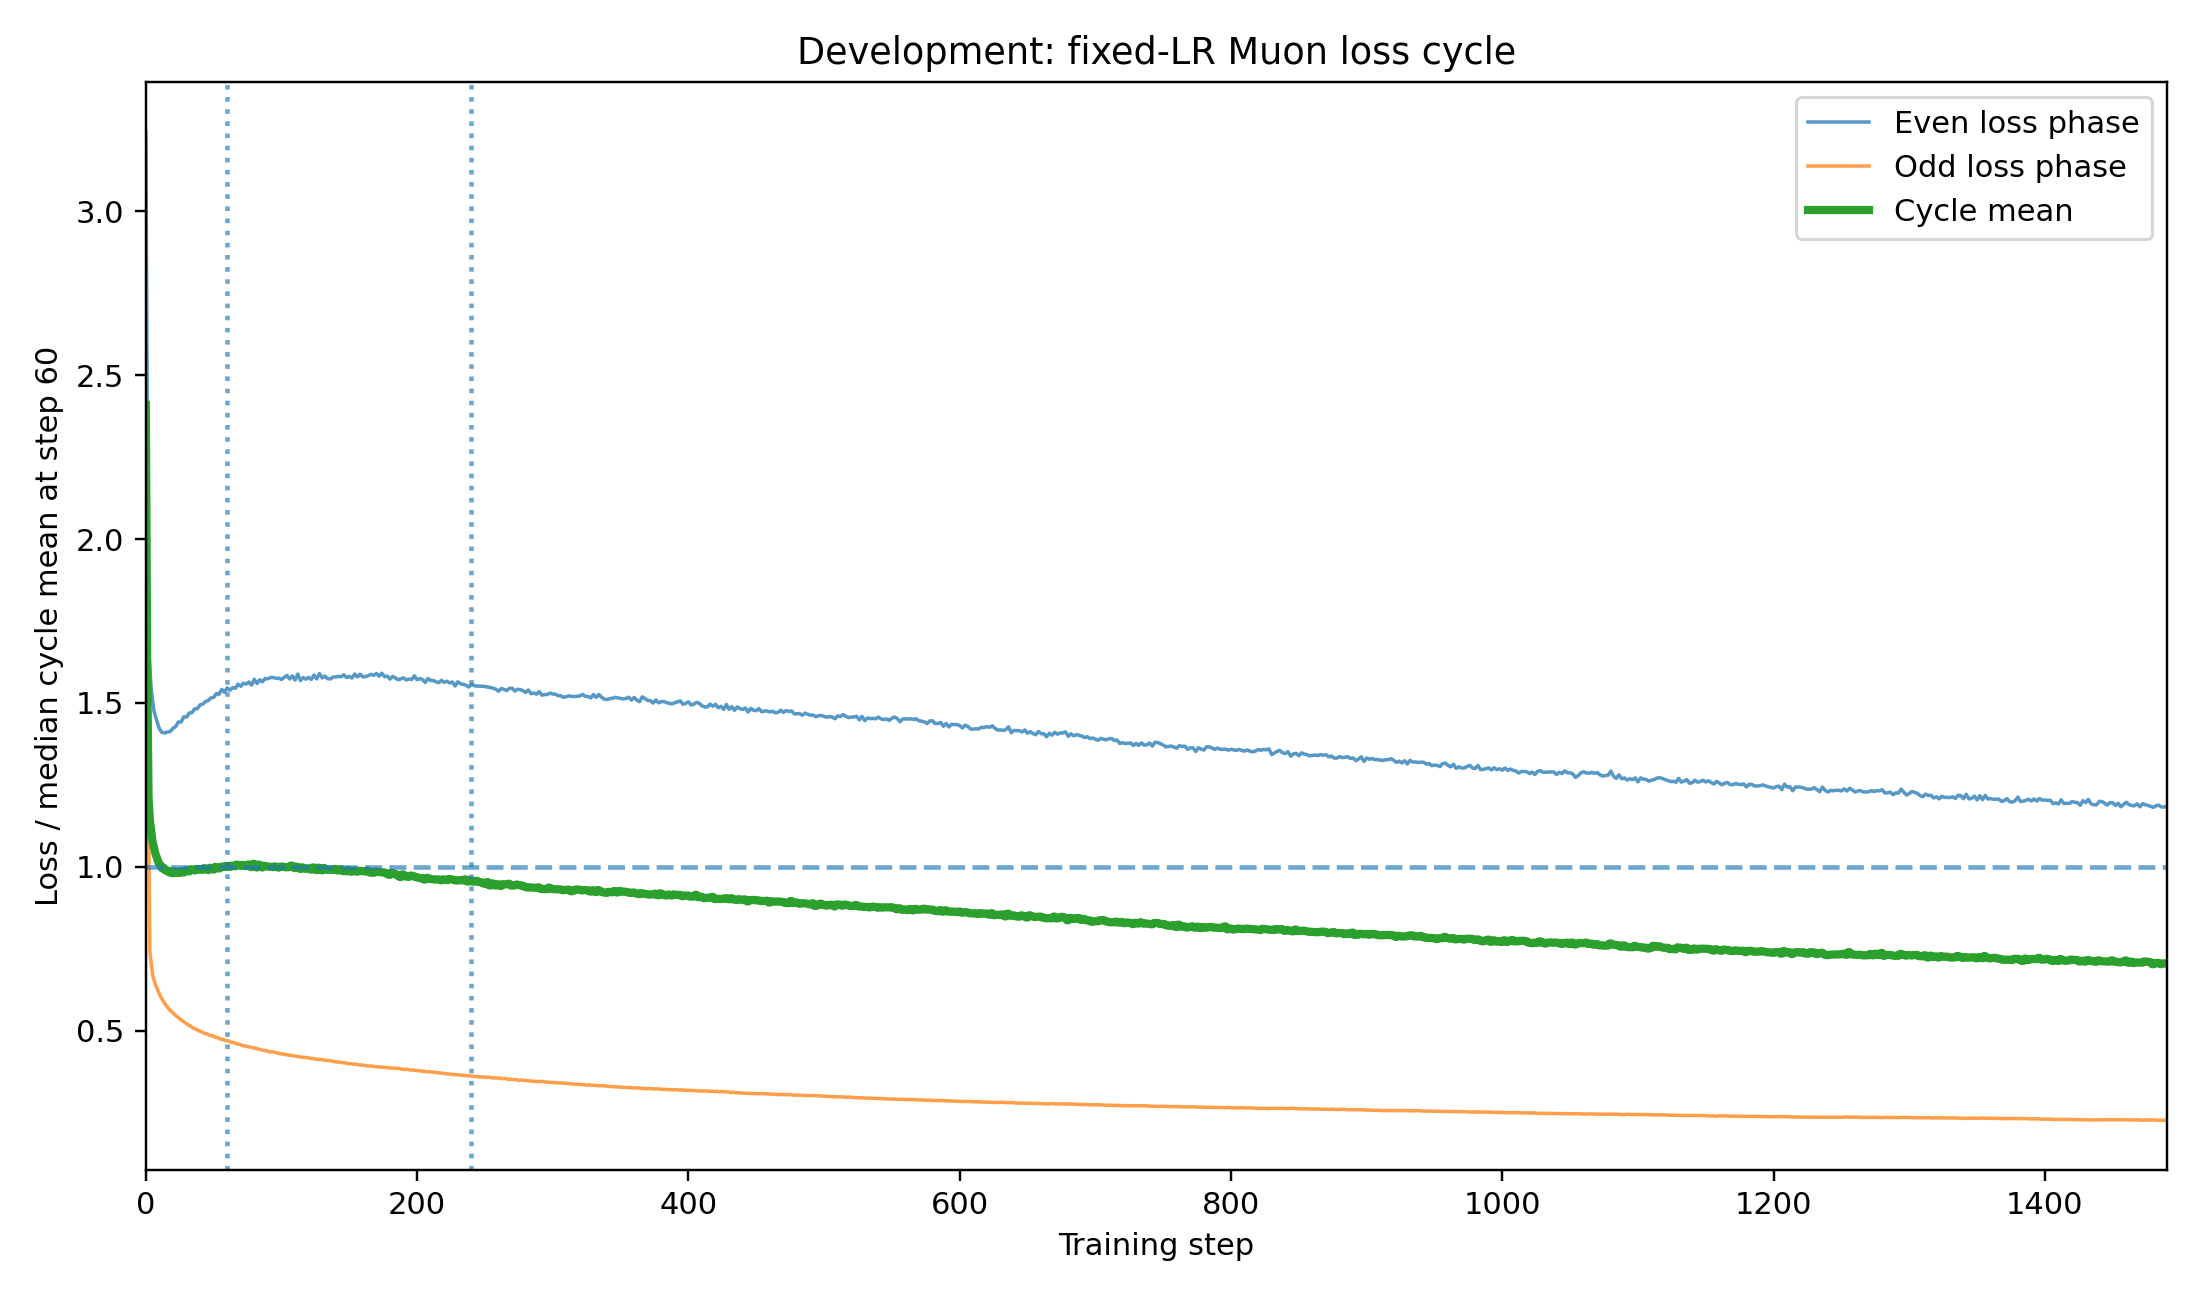

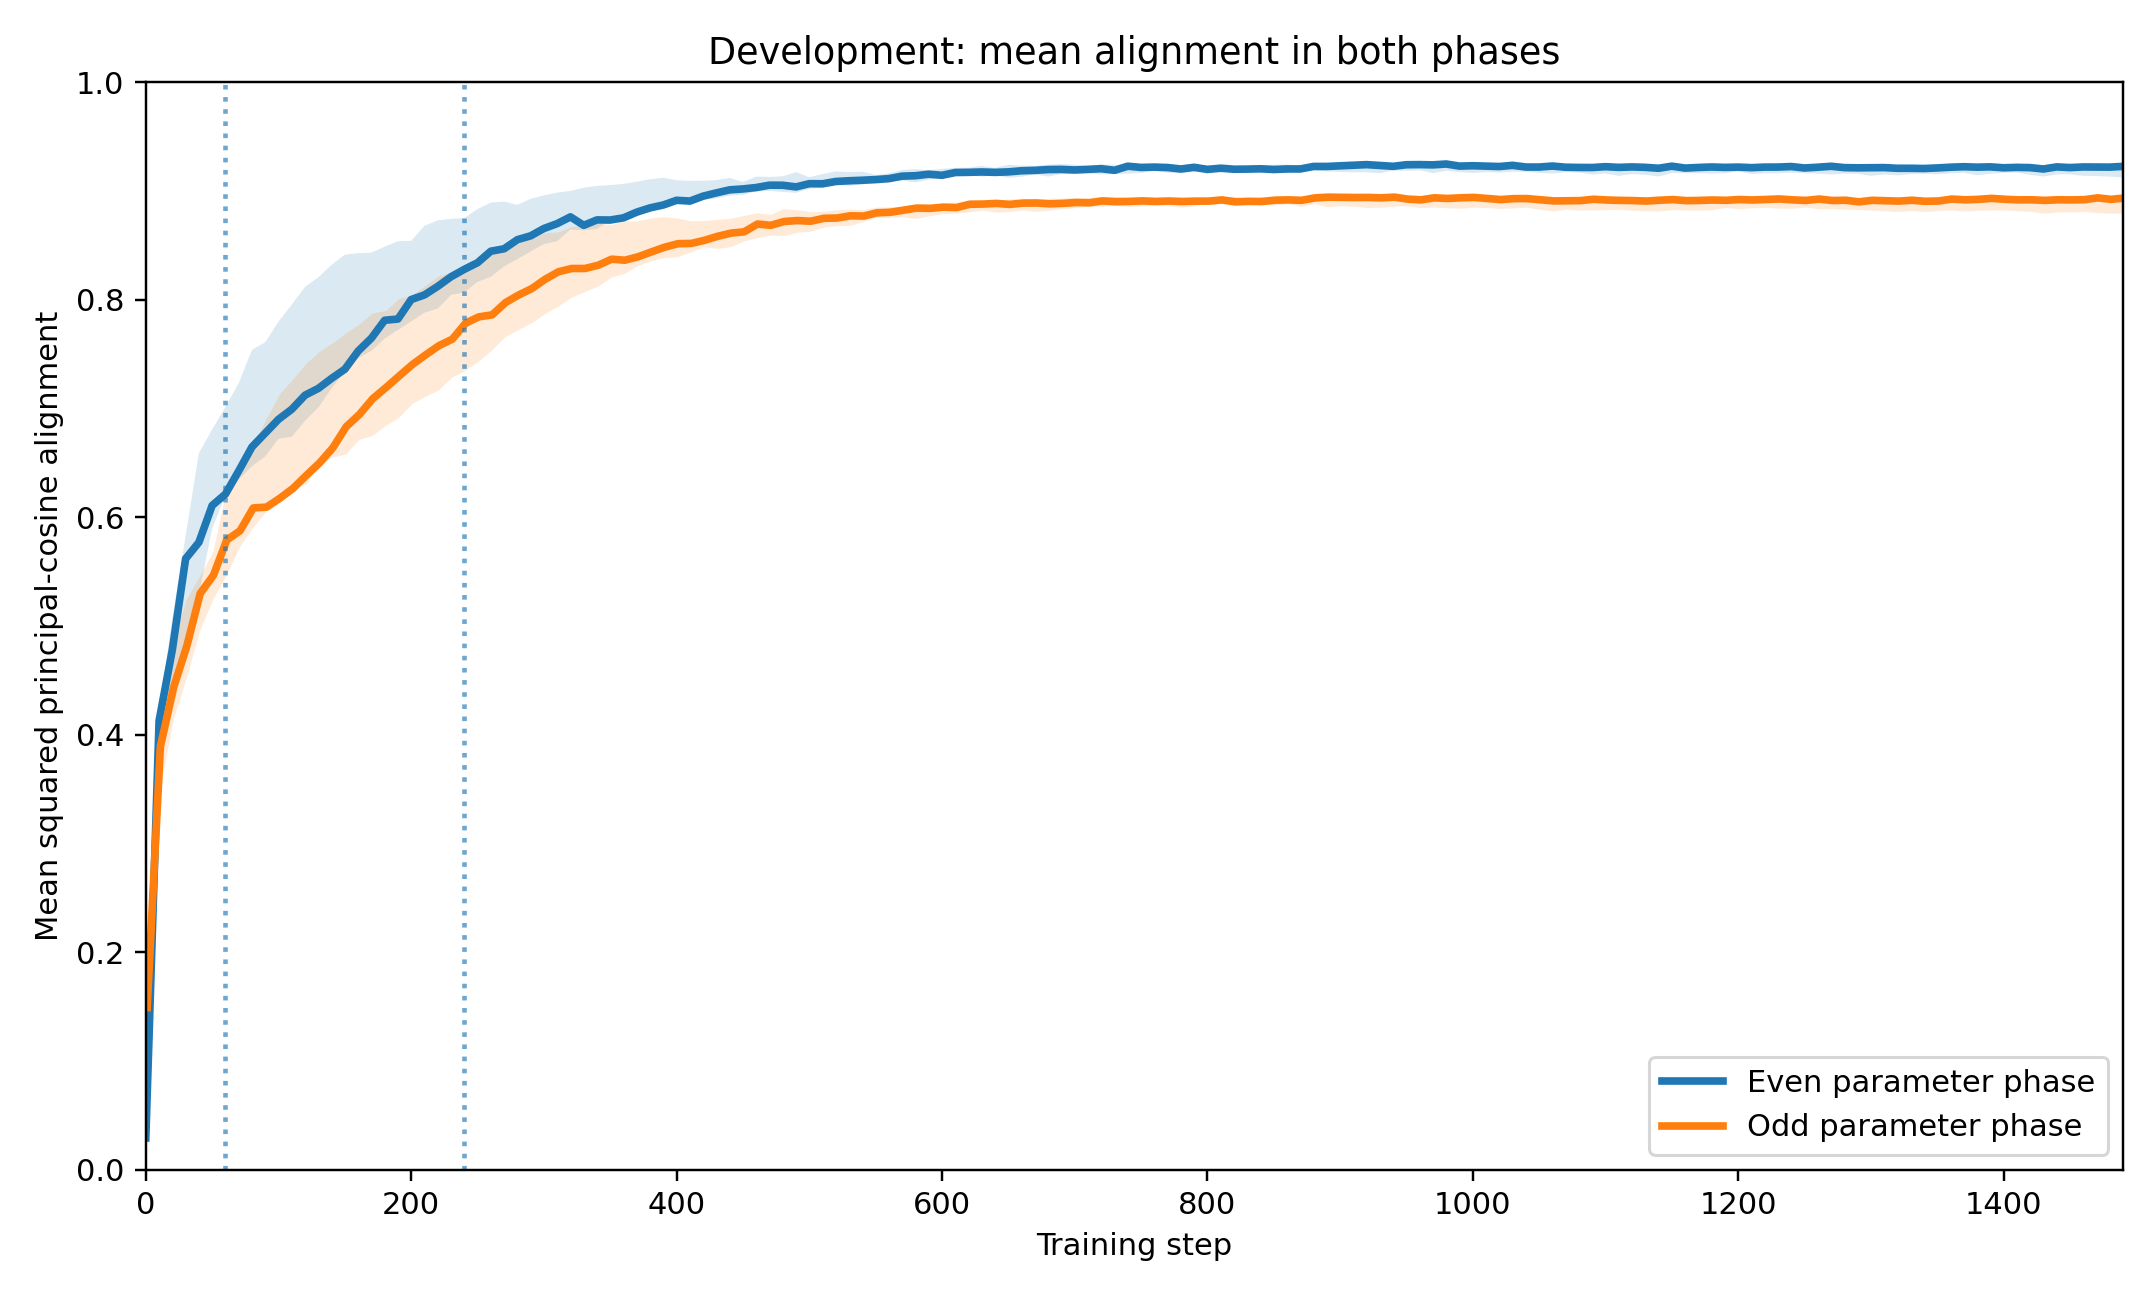

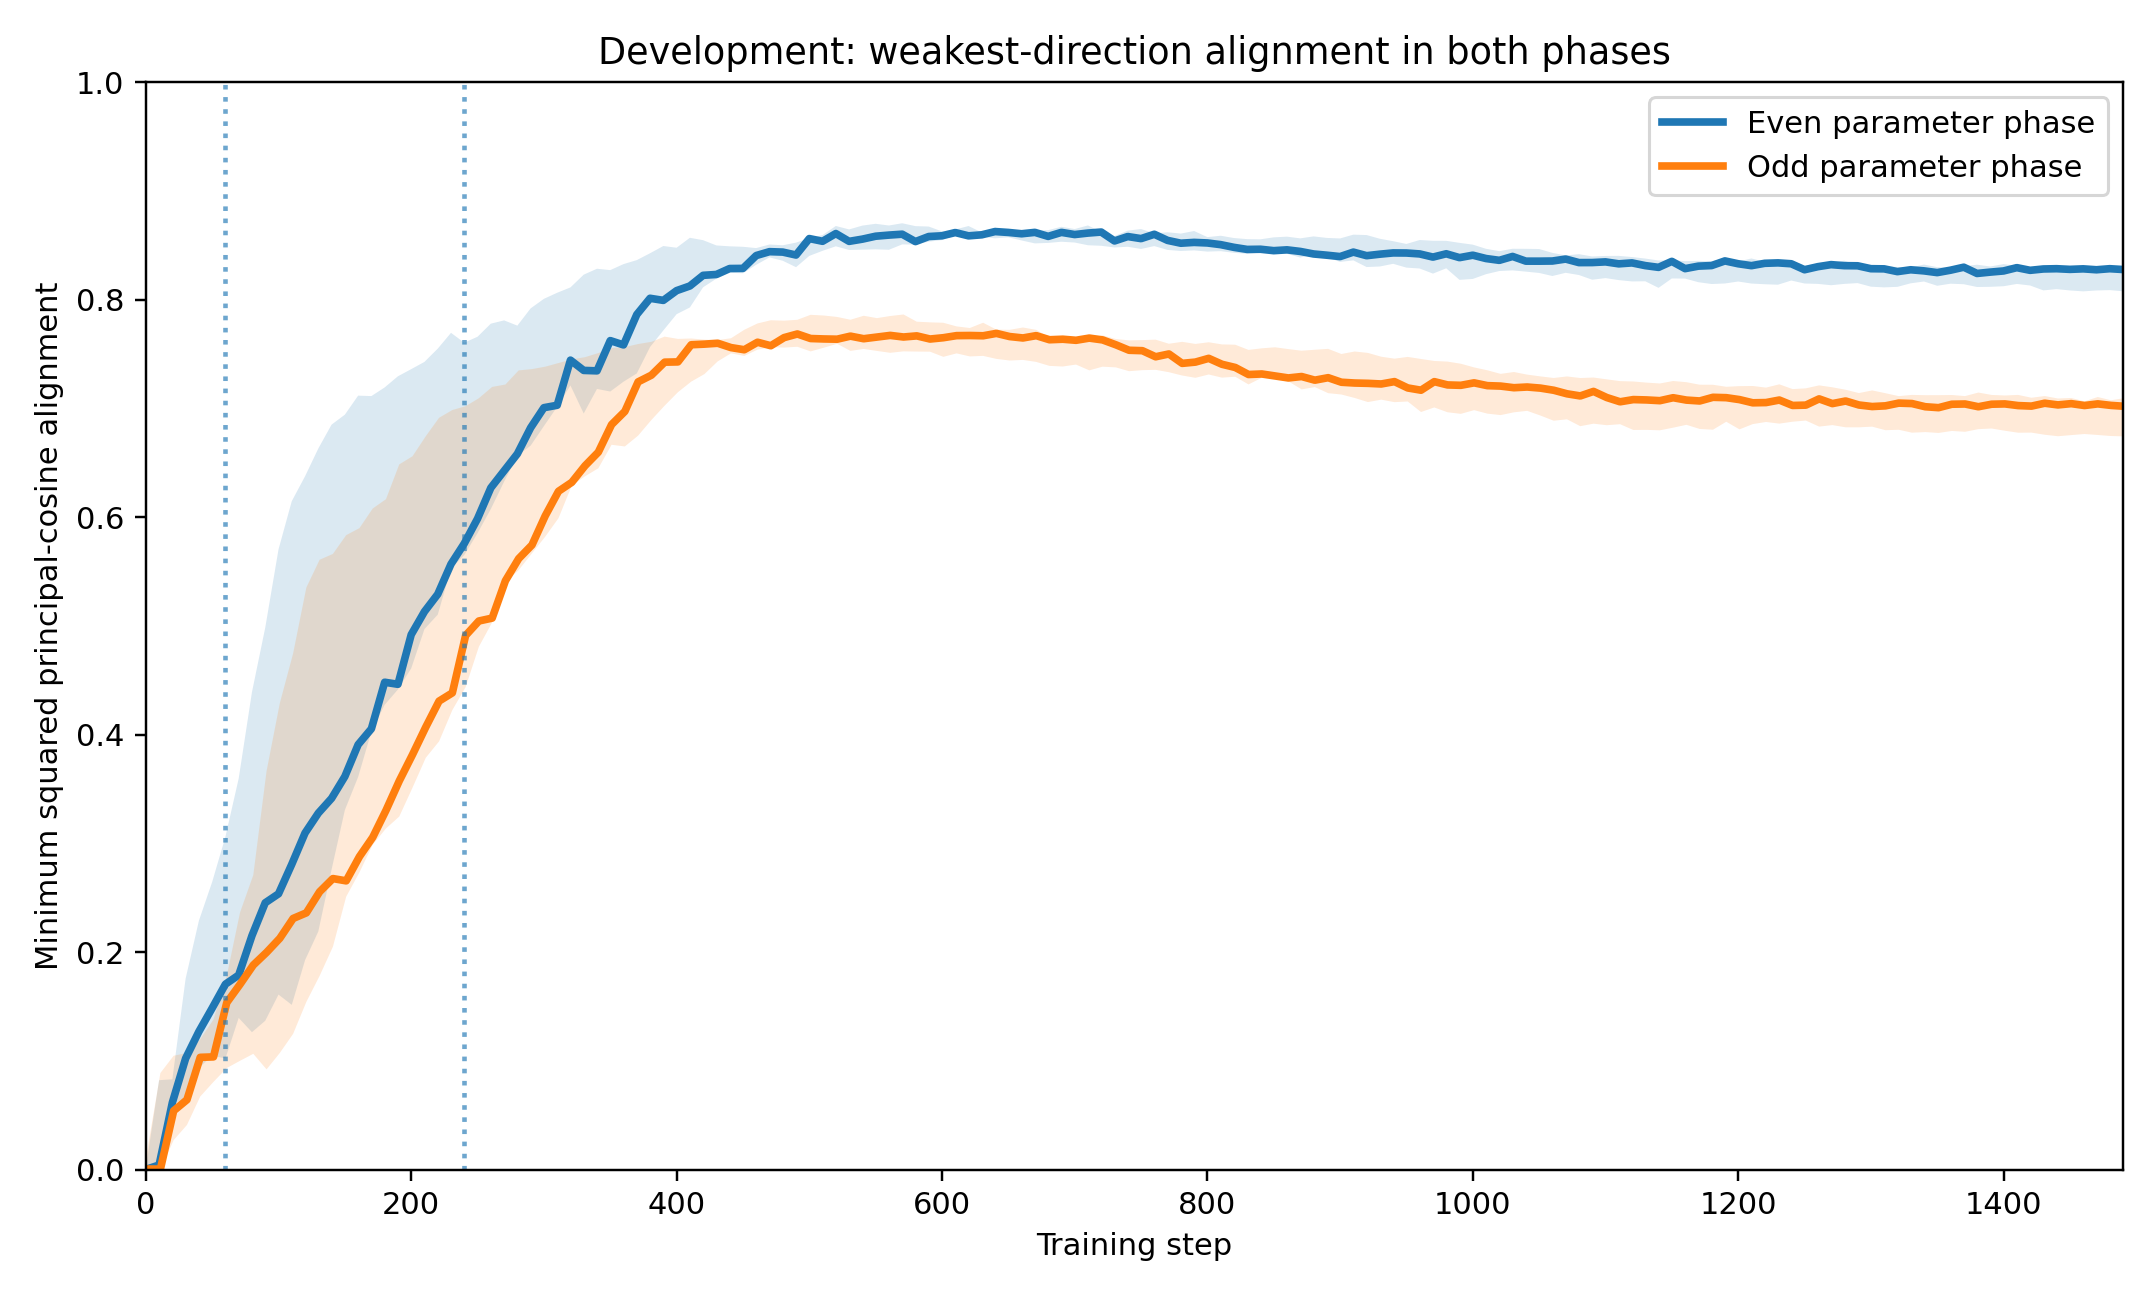

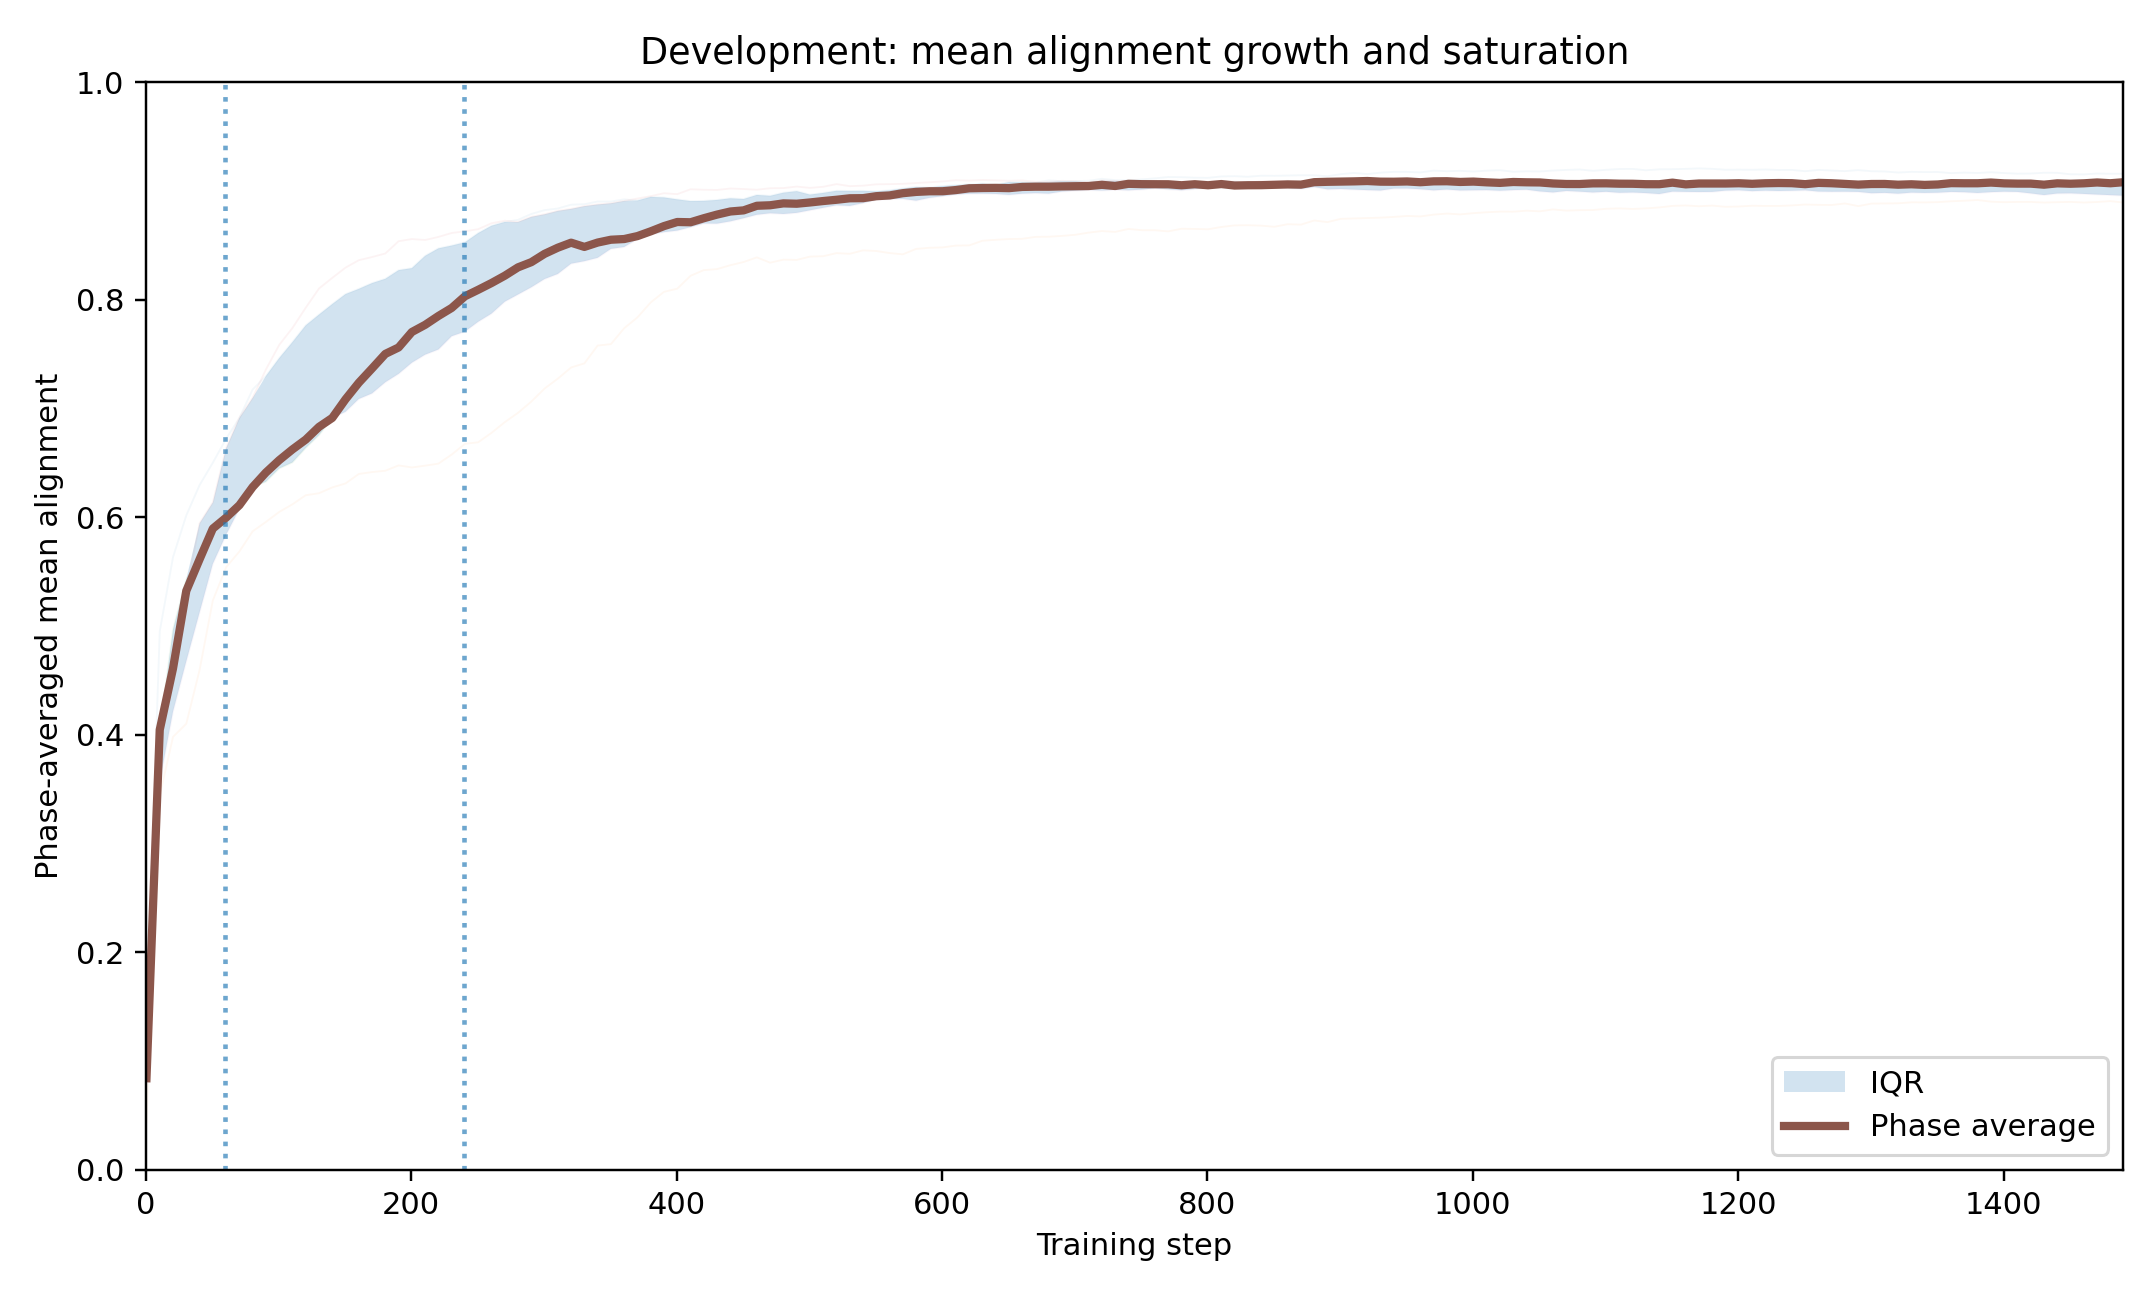

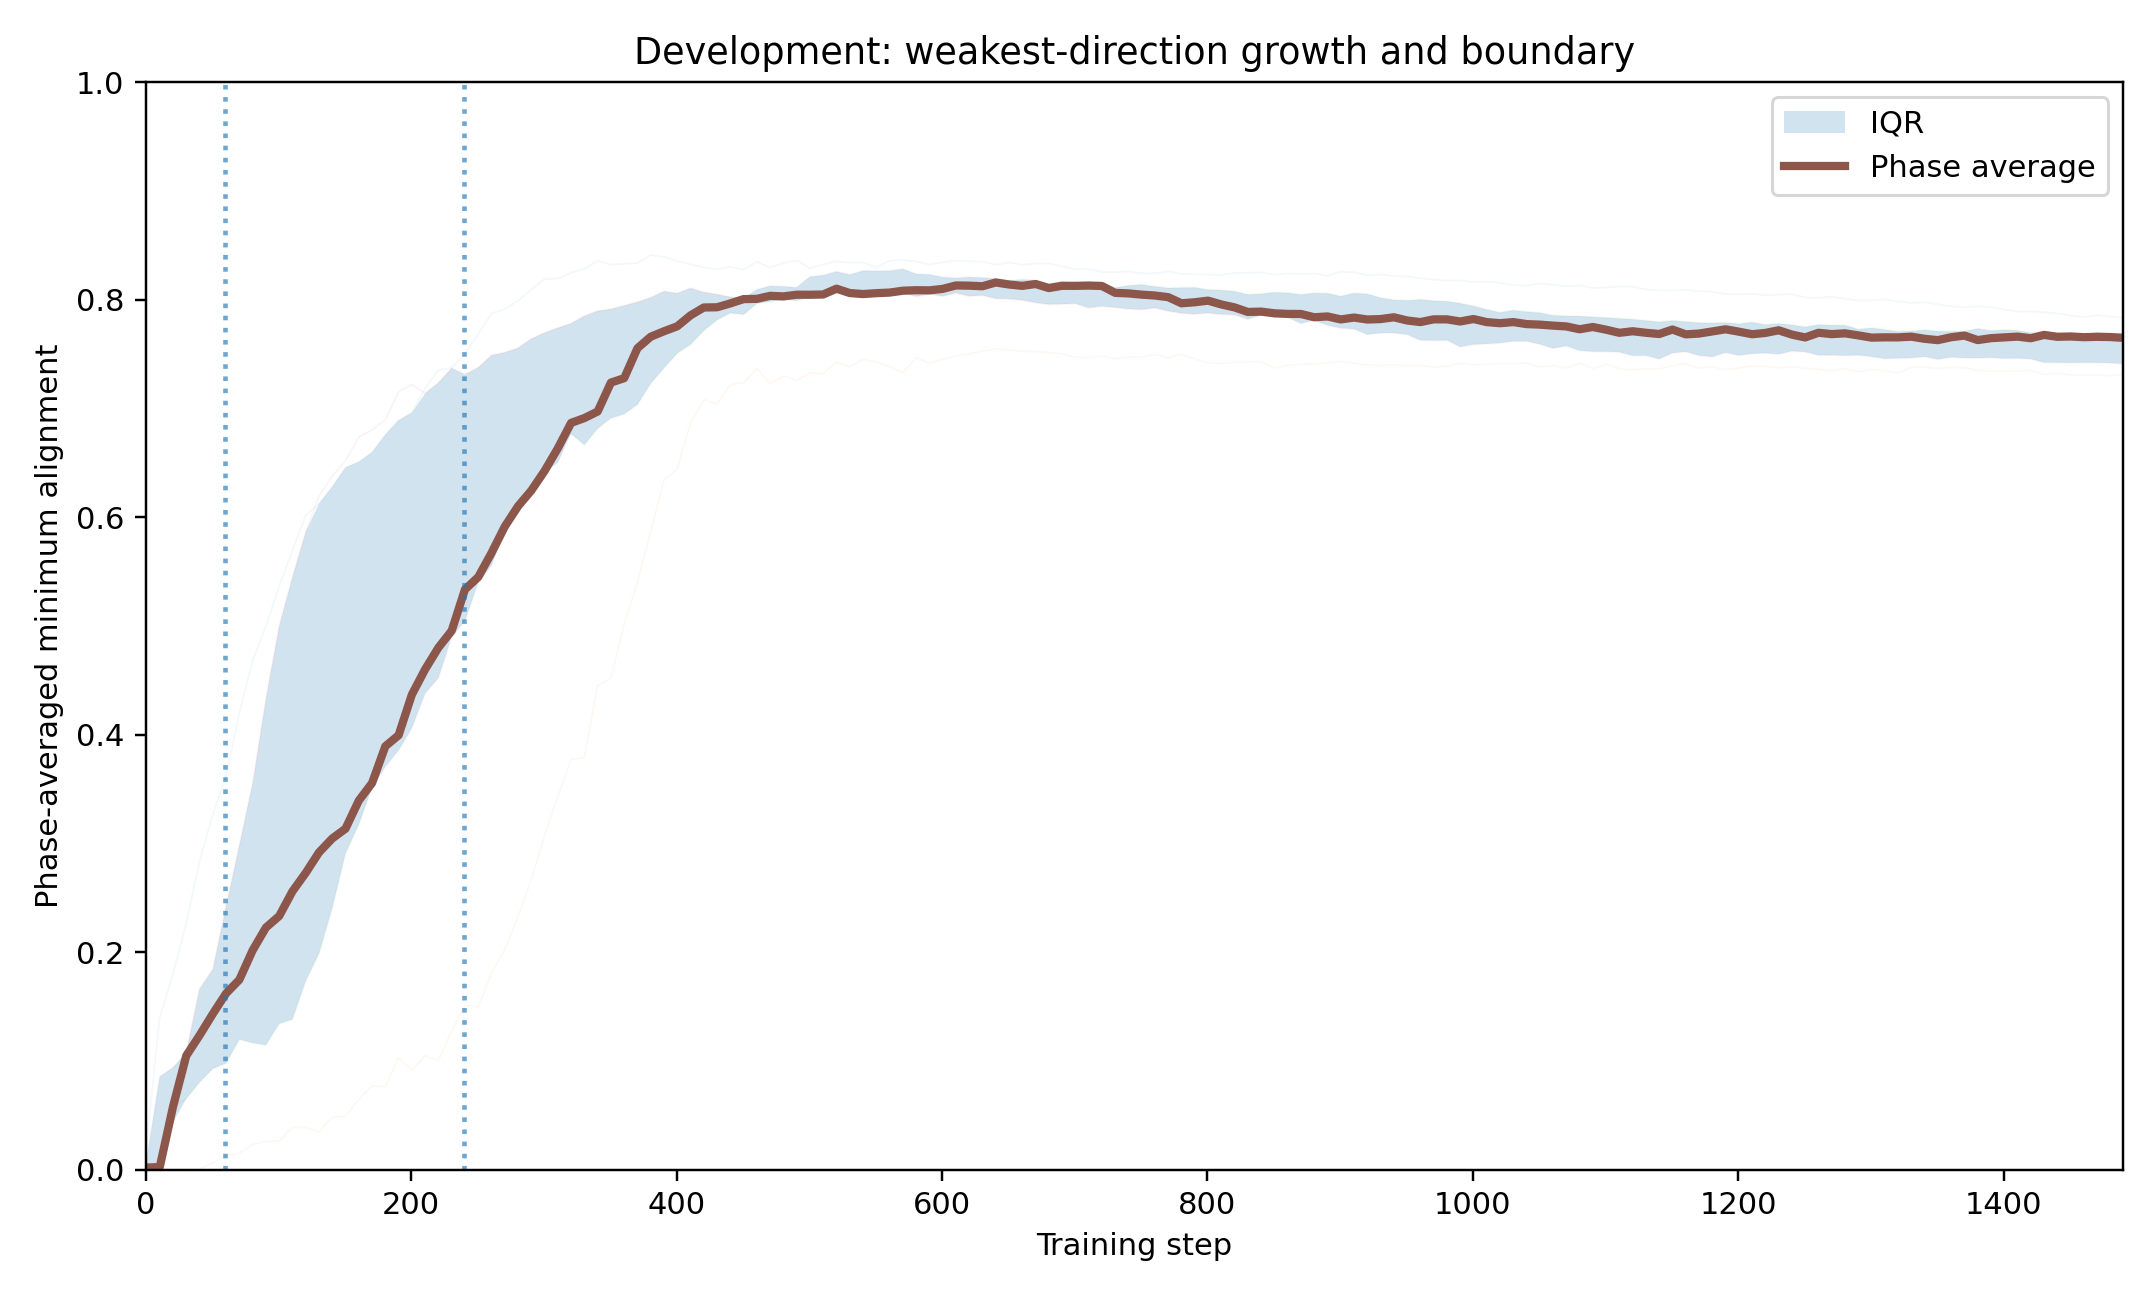

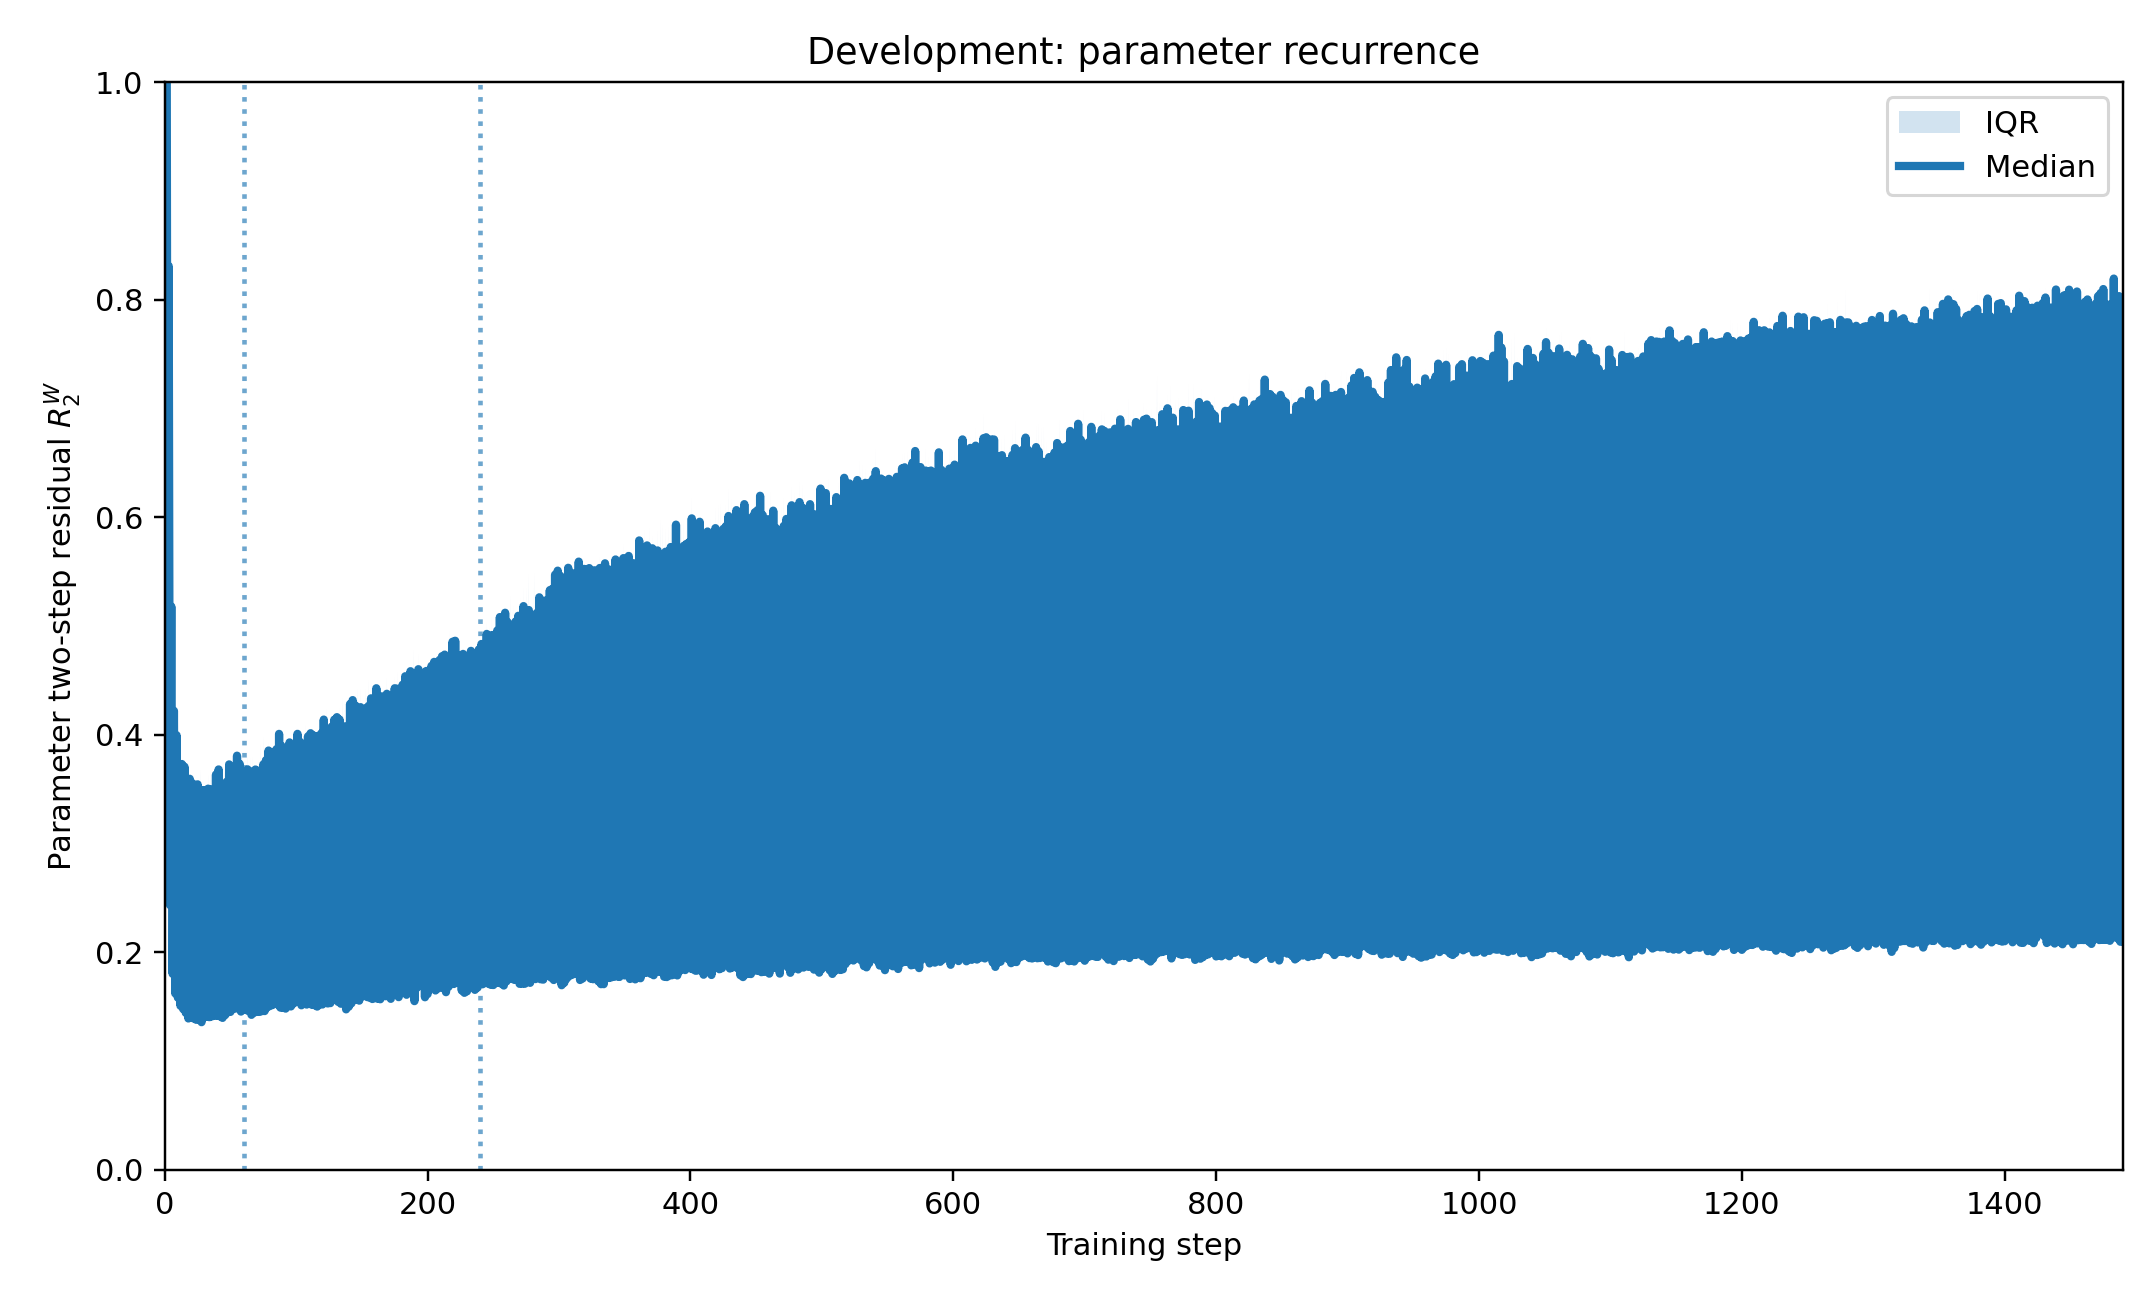

In [6]:
analysis_dir = analysis_outputs["analysis_dir"]
for group in groups:
    for filename in [
        f"{group}_loss_cycle.png",
        f"{group}_mean_alignment_two_phases.png",
        f"{group}_min_alignment_two_phases.png",
        f"{group}_mean_alignment_phase_average.png",
        f"{group}_min_alignment_phase_average.png",
        f"{group}_two_step_residual.png",
    ]:
        path = analysis_dir / filename
        if path.exists():
            display(Image(filename=str(path)))

## 5. Optional fixed-learning-rate sweep

In [ ]:
RUN_ETA_SWEEP = False
ETA_GRID = [0.4, 0.5, 0.6, 0.7, 0.8]

if RUN_ETA_SWEEP:
    sweep_config = copy.deepcopy(config)
    sweep_config["output"]["experiment_name"] = f"notebook_{PRESET}_sweep"
    sweep_table = mpm.sweep_learning_rates(
        sweep_config,
        ETA_GRID,
        group="development",
        force=FORCE_RERUN,
    )
    display(sweep_table)
else:
    print("Set RUN_ETA_SWEEP=True to run the sweep.")

The teacher basis is drawn independently in PCA coordinates. Whitening controls covariance but does not make the empirical MNIST distribution Gaussian. The task still uses teacher-generated targets.